In [2]:
from CADETProcess.optimization import OptimizationProblem
from CADETProcess.processModel import Inlet, MCT, Outlet
from CADETProcess.optimization import SLSQP, U_NSGA3, Pathos, Joblib, COBYLA, TrustConstr
from CADETProcess.processModel import ComponentSystem,MassActionLaw, LumpedRateModelWithoutPores
from CADETProcess.processModel import FlowSheet
from CADETProcess.processModel import Process
from CADETProcess.simulator import Cadet
from scipy.optimize import minimize

import logging

from IPython import display

from utils import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
df = pd.read_csv('Poplar_02_L1_M3_second_Branch_velocity_change.csv', sep=';')
data = df.to_numpy()
xi = df.columns.values[1:]
xi = [float(x) for x in xi]

t = data[2:,0]

In [4]:
xi

[0.0,
 14.28070634,
 28.32597297,
 42.47523083,
 56.61385665,
 70.76956106,
 84.72303724,
 98.946101]

In [5]:
t

array([ 10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,  55.,  60.,
        65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105., 110., 115.,
       120., 125., 130., 135., 140., 145.])

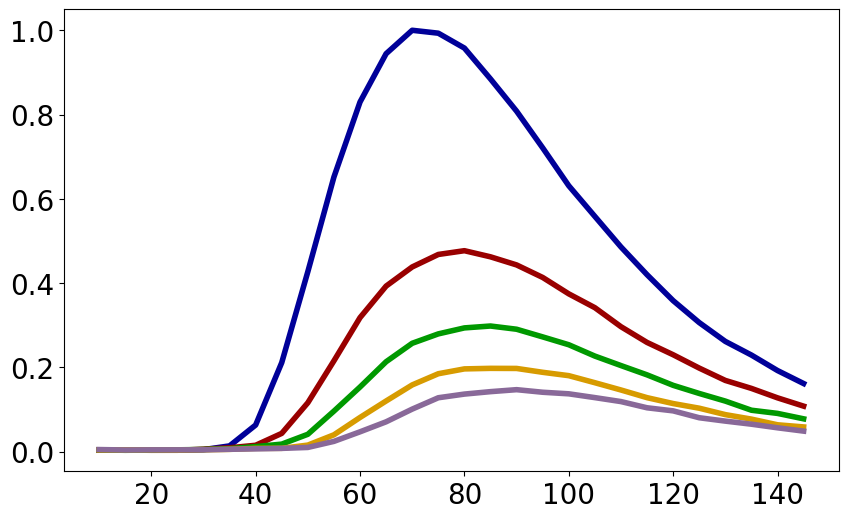

In [6]:
orig_exp_data = data[2:,1:6]
exp_data = data[2:,1:6]*np.exp(-0.00056729782996132*60*t.reshape(len(t),1))
exp_data = exp_data/np.max(exp_data)
plt.plot(t, exp_data)

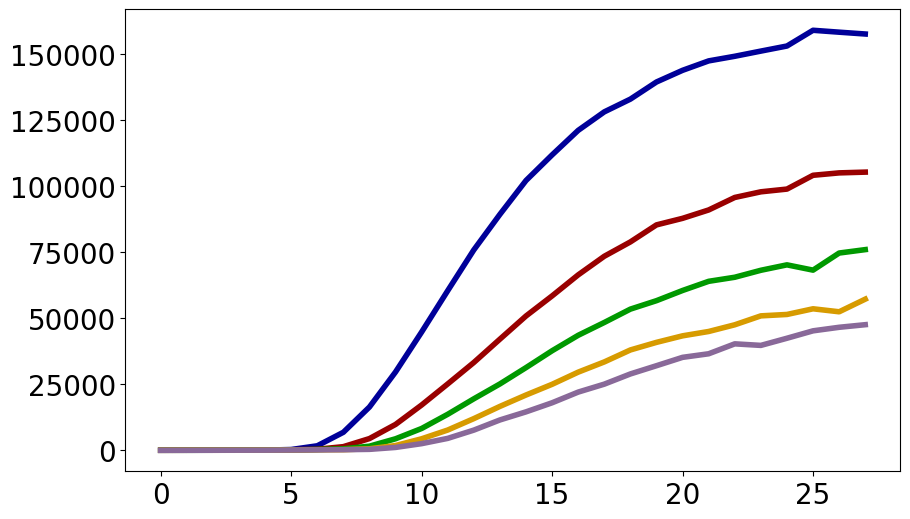

In [7]:
plt.plot(orig_exp_data)

In [8]:
def setup_process(x):
    
    p_volumetric_flow_rate_const = x[0]
    p_mct1_e12 = x[1]
    #p_mct1_e21 = x[2]
    #p_mct1_e23 = x[3]
    p_mct2_e12 = x[4]
    p_mct3_e12 = x[5]
    p_mct4_e12 = x[6]
    p_mct5_e12 = x[7]
    p_mct1_disp = x[8]
    p_mct2_disp = x[9]
    p_mct3_disp = x[10]
    p_mct4_disp = x[11]
    p_mct5_disp = x[12]
    p_total_porosity = x[13]
    p_col_dispersion = x[14]
    p_col_len = x[15]
    p_t0 = x[16]
    
  # Initialize the component system and flow sheet
    component_system = ComponentSystem(1)
    mct_flow_sheet = FlowSheet(component_system)

    # Create the units
    inlet = Inlet(component_system, name='inlet')
    leaf = LumpedRateModelWithoutPores(component_system, name='leaf')
    mct1 = MCT(component_system, nchannel=2, name='mct1')
    mct2 = MCT(component_system, nchannel=2, name='mct2')
    mct3 = MCT(component_system, nchannel=2, name='mct3')
    mct4 = MCT(component_system, nchannel=2, name='mct4')
    mct5 = MCT(component_system, nchannel=2, name='mct5')
    outlet = Outlet(component_system, name='outlet')

    leaf.discretization.ncol = 20
    mct1.discretization.ncol = 20
    mct2.discretization.ncol = 20
    mct3.discretization.ncol = 20
    mct4.discretization.ncol = 20
    mct5.discretization.ncol = 20


    reaction_system = MassActionLaw(component_system)
    reaction_system.add_reaction(
    indices=[0],
    coefficients=[-1],
    k_fwd=0.00056729782996132,
    k_bwd=0,)

    mct1.bulk_reaction_model = reaction_system
    mct2.bulk_reaction_model = reaction_system
    mct3.bulk_reaction_model = reaction_system
    mct4.bulk_reaction_model = reaction_system
    mct5.bulk_reaction_model = reaction_system


    mct_flow_sheet.add_unit(inlet)
    mct_flow_sheet.add_unit(leaf)
    mct_flow_sheet.add_unit(mct1)
    mct_flow_sheet.add_unit(mct2)
    mct_flow_sheet.add_unit(mct3)
    mct_flow_sheet.add_unit(mct4)
    mct_flow_sheet.add_unit(mct5)
    mct_flow_sheet.add_unit(outlet)

    v_lrmp = 4e-05

    leaf.total_porosity = p_total_porosity
    leaf.length = p_col_len
    leaf.diameter = x[0]/v_lrmp #np.sqrt(1/np.pi)
    leaf.axial_dispersion = p_col_dispersion

    mct_flow_sheet.add_connection(inlet, leaf)
    mct_flow_sheet.add_connection(leaf, mct1, destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct1, mct2, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct2, mct3, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct3, mct4, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct4, mct5, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct5, outlet, origin_port = 'channel_0')

    process = Process(mct_flow_sheet, 'Tracer_Transport')

    mct1.length =  xi[1]/1000
    mct2.length =  xi[2]/1000-xi[1]/1000
    mct3.length =  xi[3]/1000-xi[2]/1000
    mct4.length =  xi[4]/1000-xi[3]/1000
    mct5.length =  xi[-1]/1000-xi[4]/1000
    
    mct1.channel_cross_section_areas = [1,1] 
    mct2.channel_cross_section_areas = [1,1] 
    mct3.channel_cross_section_areas = [1,1] 
    mct4.channel_cross_section_areas = [1,1] 
    mct5.channel_cross_section_areas = [1,1] 
    
    mct1.axial_dispersion = p_mct1_disp
    mct2.axial_dispersion = p_mct2_disp
    mct3.axial_dispersion = p_mct3_disp
    mct4.axial_dispersion = p_mct4_disp
    mct5.axial_dispersion = p_mct5_disp
    
    mct1.solution_recorder.write_solution_bulk = 1
    mct2.solution_recorder.write_solution_bulk = 1
    mct3.solution_recorder.write_solution_bulk = 1
    mct4.solution_recorder.write_solution_bulk = 1
    mct5.solution_recorder.write_solution_bulk = 1


    mct1.exchange_matrix = np.array([
                                    [[0.0], [p_mct1_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])
    
    mct2.exchange_matrix =np.array([
                                    [[0.0], [p_mct2_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])
    mct3.exchange_matrix =np.array([
                                    [[0.0], [p_mct3_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])
    mct4.exchange_matrix =np.array([
                                    [[0.0], [p_mct4_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])
    mct5.exchange_matrix =np.array([
                                    [[0.0], [p_mct5_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])


    process.cycle_time = 60*t[-1]

    inlet.flow_rate = [p_volumetric_flow_rate_const, 0, 0, 0]

    _ = process.add_event('Base', 'flow_sheet.inlet.c', [0], 0)
    _ = process.add_event('Start', 'flow_sheet.inlet.c', [100], p_t0*600)
    _ = process.add_event('Stop', 'flow_sheet.inlet.c', [0], p_t0*600+60)
    
    return process

In [9]:
xi

[0.0,
 14.28070634,
 28.32597297,
 42.47523083,
 56.61385665,
 70.76956106,
 84.72303724,
 98.946101]

In [10]:
# Define the cubic polynomial function
def cubic_polynomial(t, a, b, c, d):
    return a * t**3 + b * t**2 + c * t + d

In [11]:
a, b, c, d = reversed([8.46147043e-05, 1.27049087e-09, 0, 0])

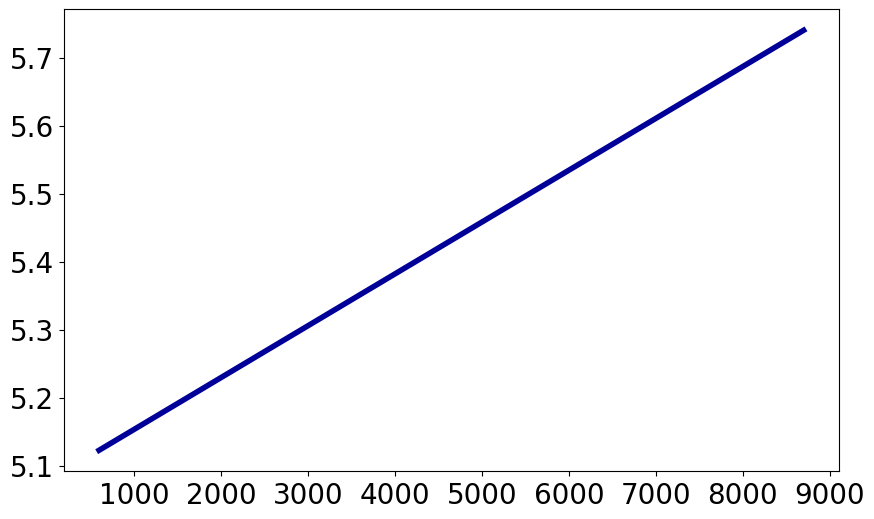

In [12]:
plt.plot(t*60,cubic_polynomial(t*60, a, b, c, d)*60000)

In [13]:
6.16752725e-05*6000

0.37005163500000005

In [14]:
1.08112738e-04*60000*0.99

6.4218966372

In [15]:
cubic_polynomial(t*60, a, b, c, d)

array([8.53769988e-05, 8.57581461e-05, 8.61392933e-05, 8.65204406e-05,
       8.69015879e-05, 8.72827351e-05, 8.76638824e-05, 8.80450296e-05,
       8.84261769e-05, 8.88073242e-05, 8.91884714e-05, 8.95696187e-05,
       8.99507660e-05, 9.03319132e-05, 9.07130605e-05, 9.10942077e-05,
       9.14753550e-05, 9.18565023e-05, 9.22376495e-05, 9.26187968e-05,
       9.29999440e-05, 9.33810913e-05, 9.37622386e-05, 9.41433858e-05,
       9.45245331e-05, 9.49056803e-05, 9.52868276e-05, 9.56679749e-05])

In [16]:
# Define min and max values for each parameter

param_bounds = {
    'volumetric_flow_rate_const': (1e-05, 2e-04),  # log-scaling
    'mct1_e12': (1e-10, 20),  # log-scaling
    'mct1_e21': (1e-10, 20),  # log-scaling
    'mct1_e23': (1e-10, 20),  # log-scaling
    'mct2_e12': (1e-10, 20),  # log-scaling
    'mct3_e12': (1e-10, 20),  # log-scaling
    'mct4_e12': (1e-10, 20),  # log-scaling
    'mct5_e12': (1e-10, 20),  # log-scaling
    'disp1': (1e-16, 1e-3),   # log-scaling
    'disp2': (1e-17, 1e-2),   # log-scaling
    'disp3': (1e-10, 1e-2),   # log-scaling
    'disp4': (1e-10, 1e-2),   # log-scaling
    'disp5': (1e-10, 1e-2),   # log-scaling
    'total_porosity': (0.1, 0.99),     # linear scaling
    'col_dispersion': (1e-07, 1e-06),  # log-scaling
    'col_len': (0.01, 0.3),            # linear scaling
    't0': (0.1, 2),                    # linear scaling
}



def analyze_parameters(norm_param_values, param_bounds=param_bounds):
    """
    Analyze parameters and print their names, denormalized values, and normalized values.

    Args:
        norm_param_values (list): Normalized parameter values (0-1 range).
        param_bounds (dict): Dictionary with parameter names as keys and boundary tuples as values.

    Returns:
        None: Prints the analysis.
    """
    print(f"{'Name':<30}{'Denormalized Value':<20}{'Normalized Value':<10}")
    print("-" * 65)

    # Denormalize parameters
    param_values = denormalize_parameters(norm_param_values)

    for i, (name, bounds) in enumerate(param_bounds.items()):
        value = param_values[i]
        norm_param = norm_param_values[i]

        print(f"{name:<30}{value:<20.8e}{norm_param:<10.2f}")

def normalize_parameters(x):
    normalized_x = []
    for i, param in enumerate(param_bounds):
        min_val, max_val = param_bounds[param]
        
        if min_val > 0 and (max_val / min_val) > 100:  # If the range is large, use log scaling
            norm_param = (np.log(x[i]) - np.log(min_val)) / (np.log(max_val) - np.log(min_val))
        else:  # For compact ranges, use min-max scaling
            norm_param = (x[i] - min_val) / (max_val - min_val)
        
        normalized_x.append(norm_param)
    
    return np.array(normalized_x)

def denormalize_parameters(norm_x):
    x = []
    for i, param in enumerate(param_bounds):
        min_val, max_val = param_bounds[param]
        
        if min_val > 0 and (max_val / min_val) > 100:  # Log scaling for large ranges
            param_value = np.exp(norm_x[i] * (np.log(max_val) - np.log(min_val)) + np.log(min_val))
        else:  # Min-max scaling for compact ranges
            param_value = norm_x[i] * (max_val - min_val) + min_val
        
        x.append(param_value)
    
    return np.array(x)

In [17]:
[x / 1000 for x in xi]

[0.0,
 0.01428070634,
 0.02832597297,
 0.04247523083,
 0.05661385665,
 0.07076956106,
 0.08472303724,
 0.098946101]

In [18]:
xi[1]/1000, xi[2]/1000-xi[1]/1000 , xi[3]/1000-xi[2]/1000, xi[4]/1000-xi[3]/1000,xi[-1]/1000-xi[4]/1000

(0.01428070634,
 0.014045266629999999,
 0.014149257860000004,
 0.01413862582,
 0.04233224434999999)

In [19]:
(xi[1]/1000)+(xi[2]/1000-xi[1]/1000)+(xi[3]/1000-xi[2]/1000)+(xi[4]/1000-xi[3]/1000)+(xi[-1]/1000-xi[4]/1000)
    

0.098946101

In [20]:
lenghts = [x / 1000 for x in xi]

eval_location1 = lenghts[0:1] 
eval_location2 = list(np.array(lenghts[1:2])-lenghts[1])
eval_location3 = list(np.array(lenghts[2:3])-lenghts[2])
eval_location4 = list(np.array(lenghts[3:4])-lenghts[3])
eval_location5 = list(np.array(lenghts[4:])-lenghts[4])



eval_location1,eval_location2, eval_location3, eval_location4, eval_location5

([0.0],
 [np.float64(0.0)],
 [np.float64(0.0)],
 [np.float64(0.0)],
 [np.float64(0.0),
  np.float64(0.014155704409999997),
  np.float64(0.02810918058999999),
  np.float64(0.04233224434999999)])

In [21]:
lenghts[0:1],lenghts[1:3], lenghts[3:4], lenghts[4:]

([0.0],
 [0.01428070634, 0.02832597297],
 [0.04247523083],
 [0.05661385665, 0.07076956106, 0.08472303724, 0.098946101])

In [22]:
def mct_obj(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]
    mct4 = process.flow_sheet.units[5]
    mct5 = process.flow_sheet.units[6]
    


    lenghts = [x / 1000 for x in xi]

    eval_location1 = lenghts[0:1] 
    eval_location2 = list(np.array(lenghts[1:2])-lenghts[1])
    eval_location3 = list(np.array(lenghts[2:3])-lenghts[2])
    eval_location4 = list(np.array(lenghts[3:4])-lenghts[3])
    eval_location5 = list(np.array(lenghts[4:])-lenghts[4])

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 = np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 = np.atleast_2d(np.sum(cb_mct3, axis=2).squeeze()).T

    cb_mct4 = interpolate_cb_from_simulation_results(simulation_results, mct4, time_new, axial_positions_new = eval_location4)
    calc_data_mct4 = np.atleast_2d(np.sum(cb_mct4, axis=2).squeeze()).T
    
    cb_mct5 = interpolate_cb_from_simulation_results(simulation_results, mct5, time_new, axial_positions_new = eval_location5)
    calc_data_mct5 = np.sum(cb_mct5, axis=2).squeeze()


    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3,calc_data_mct4, calc_data_mct5))
    calc_data = calc_data/np.max(calc_data)
    
    res=(calc_data.ravel()-exp_data.ravel())**2
    res=np.sum(res)
    
    plot_fit(time_new, calc_data, exp_data)

    
    print(x, res)

    return res

def mct_obj_res(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]
    mct4 = process.flow_sheet.units[5]
    mct5 = process.flow_sheet.units[6]
    


    lenghts = [x / 1000 for x in xi]

    eval_location1 = lenghts[0:1] 
    eval_location2 = list(np.array(lenghts[1:2])-lenghts[1])
    eval_location3 = list(np.array(lenghts[2:3])-lenghts[2])
    eval_location4 = list(np.array(lenghts[3:4])-lenghts[3])
    eval_location5 = list(np.array(lenghts[4:])-lenghts[4])

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 = np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 = np.atleast_2d(np.sum(cb_mct3, axis=2).squeeze()).T

    cb_mct4 = interpolate_cb_from_simulation_results(simulation_results, mct4, time_new, axial_positions_new = eval_location4)
    calc_data_mct4 = np.atleast_2d(np.sum(cb_mct4, axis=2).squeeze()).T
    
    cb_mct5 = interpolate_cb_from_simulation_results(simulation_results, mct5, time_new, axial_positions_new = eval_location5)
    calc_data_mct5 = np.sum(cb_mct5, axis=2).squeeze()


    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3,calc_data_mct4, calc_data_mct5))
    calc_data = calc_data/np.max(calc_data)
    
    res=(calc_data.ravel()-exp_data.ravel())
    ssq=np.sum(res**2)
    
    plot_fit(time_new, calc_data, exp_data)

    
    print(x, res)

    return res

def mct_full_result(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]
    mct4 = process.flow_sheet.units[5]
    mct5 = process.flow_sheet.units[6]
    


    lenghts = [x / 1000 for x in xi]

    eval_location1 = lenghts[0:1] 
    eval_location2 = list(np.array(lenghts[1:2])-lenghts[1])
    eval_location3 = list(np.array(lenghts[2:3])-lenghts[2])
    eval_location4 = list(np.array(lenghts[3:4])-lenghts[3])
    eval_location5 = list(np.array(lenghts[4:])-lenghts[4])

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 = np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 = np.atleast_2d(np.sum(cb_mct3, axis=2).squeeze()).T

    cb_mct4 = interpolate_cb_from_simulation_results(simulation_results, mct4, time_new, axial_positions_new = eval_location4)
    calc_data_mct4 = np.atleast_2d(np.sum(cb_mct4, axis=2).squeeze()).T
    
    cb_mct5 = interpolate_cb_from_simulation_results(simulation_results, mct5, time_new, axial_positions_new = eval_location5)
    calc_data_mct5 = np.sum(cb_mct5, axis=2).squeeze()


    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3,calc_data_mct4, calc_data_mct5))
    calc_data = calc_data/np.max(calc_data)

    
    plot_fit(time_new, calc_data, exp_data)

    return calc_data

In [23]:
def plot_fit(time, calc_data, experimental_data):

    display.clear_output(wait=True)

    calc_data = calc_data/np.max(calc_data)
    
    res=np.sum(((calc_data.ravel()-exp_data.ravel())**2).reshape(28,8),axis=1)
    

    fig = plt.figure(figsize=(15,5))
    ax1 = fig.add_subplot(121)
    ax1.plot(time,calc_data[:,0:1], label="mct1", color='k', linewidth=1)
    ax1.plot(time,calc_data[:,1:2], label="mct2", color='r', linewidth=1)
    ax1.plot(time,calc_data[:,2:3], label="mct3", color='b', linewidth=1)
    ax1.plot(time,calc_data[:,3:4], label="mct4", color='g', linewidth=1)
    ax1.plot(time,calc_data[:,4:], label="mct5", color='y', linewidth=1)
    ax1.plot(time,res, label="res", color='b')
    ax1.plot(time,experimental_data,'.')
    
    #ax1.legend()

    # ax2 = fig.add_subplot(132)

    # ax3 = fig.add_subplot(133)
    # ax3.plot(self.ssq_list, label=ssq)
    # v_text='v:'+str(v)
    # ax3.set_title(v_text)
    # ax3.legend()

    display.display(fig)
    plt.close(fig)
    

In [25]:
simulator = Cadet()    

# optimization_problem.add_objective(
#     mct_obj,
#     n_objectives=1,
# )


In [26]:
normalize_parameters([8.46147043e-05, 8.79826751e-03, 6.59526351e-03,
 1.45144017e-03, 1.28111262e-03, 1.21724995e-03, 1.04609671e-03,
 1.50470319e-03, 2.69516532e-08, 3.16227766e-16, 3.56134396e-07,
 2.11367047e-06, 1.05671551e-06, 4.78138065e-01, 7.13260810e-07,
 1.75227068e-01, 1.75552387e+00] )

array([0.39270897, 0.70297992, 0.69190438, 0.63372977, 0.6289327 ,
       0.62696761, 0.62114443, 0.63511475, 0.64850657, 0.1       ,
       0.44395174, 0.54062966, 0.50299476, 0.42487423, 0.6814009 ,
       0.56974851, 0.87132835])

In [27]:
analyze_parameters([0.38522691, 0.68945403, 0.67324479, 0.6262959 , 0.62460321,
       0.62161835, 0.61759845, 0.63007586, 0.64661502, 0.1       ,
       0.44405907, 0.54067494, 0.50430362, 0.42116897, 0.67941026,
       0.57056685, 0.87104099])

Parameter 0: ±5.353987077459486%
Parameter 1: ±0.9464291370246193%
Parameter 2: ±1.1587851460693062%
Parameter 3: ±1.5839819269236703%
Parameter 4: ±0.7601936978187565%
Parameter 5: ±0.98089606270595%
Parameter 6: ±1.227192321451014%
Parameter 7: ±1.630556703771455%
Parameter 8: ±9.846159215910186%
Parameter 9: ±4.8646281460923045e-05%
Parameter 10: ±2.493441740221192%
Parameter 11: ±4.34868286723285%
Parameter 12: ±1.1442786366710729%
Parameter 13: ±7.206869049310622%
Parameter 14: ±1.5095522649986741%
Parameter 15: ±0.3497795470366269%
Parameter 16: ±0.0%

SyntaxError: invalid character '±' (U+00B1) (778673775.py, line 6)

In [28]:
 mct_obj([0.38522691, 0.68945403, 0.67324479, 0.6262959 , 0.62460321,
       0.62161835, 0.61759845, 0.63007586, 0.64661502, 0.1       ,
       0.44405907, 0.54067494, 0.50430362, 0.42116897, 0.67941026,
       0.57056685, 0.87104099]
)

IndentationError: unexpected indent (2618648642.py, line 1)

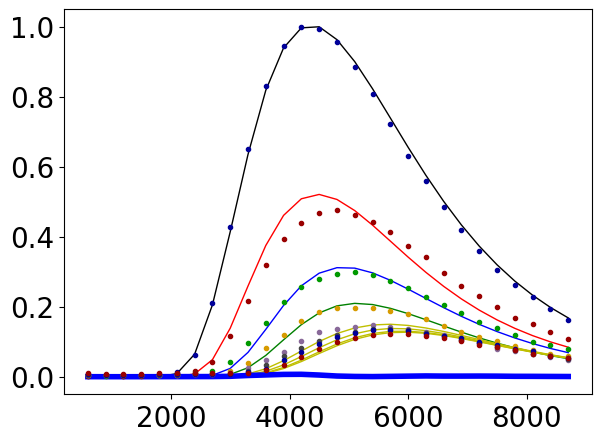

[5.61947404e-05 1.22196818e-03 6.59526351e-03 1.45144017e-03
 8.00878327e-04 9.87130330e-04 9.30968422e-04 3.75992651e-03
 5.09942797e-10 3.16227558e-16 1.06878965e-06 2.60152331e-06
 2.35973608e-06 6.27727276e-01 7.42028673e-07 1.88143052e-01
 1.78197672e+00] 0.05314502499753471


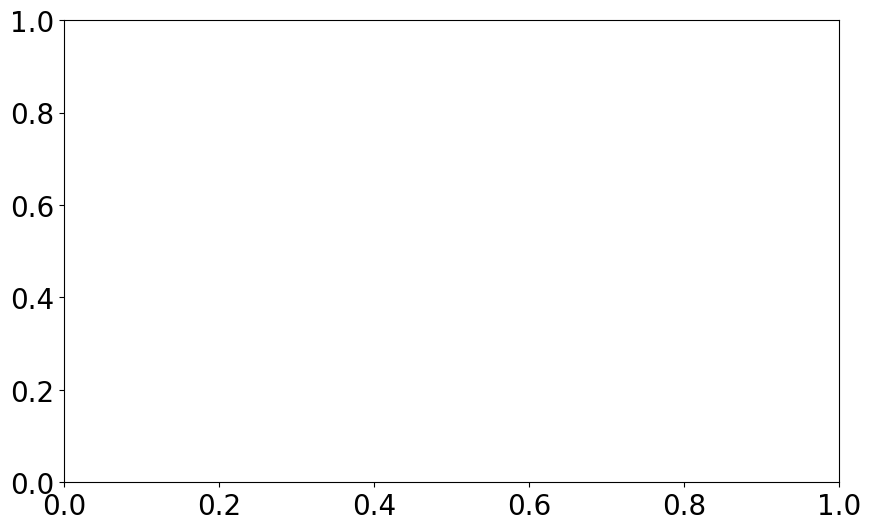

In [29]:
x0 = np.array([0.39270897, 0.70297992, 0.69190438, 0.63372977,
       0.6289327 , 0.62696761, 0.62114443, 0.63511475, 0.64850657,
       0.1       , 0.44395174, 0.54062966, 0.50299476, 0.42487423,
       0.6814009 , 0.56974851, 0.87132835]

)




# Initialize the plot
fig, ax = plt.subplots()

fig.canvas.draw()
display.display(fig)

result_fd = minimize(
    fun=mct_obj,
    x0=x0,
    method='L-BFGS-B',
    bounds=(17*((0,1),)),
    options={'disp':True, 'maxiter': 1000, 'eps':1e-3, 'finite_diff_rel_step':1},
    
)




In [30]:
result_fd.x


array([0.24313021, 0.62711628, 0.69190438, 0.63372977, 0.61087941,
       0.61891478, 0.6166637 , 0.67030876, 0.51596319, 0.09999998,
       0.50361153, 0.55190347, 0.54660793, 0.592952  , 0.71336519,
       0.61428639, 0.88425091])

In [ ]:
# jac
# [ 2.45363047e-01,  2.07126348e+00,  1.22437622e+00,  4.89009796e-01,
#         5.24242232e-01, -4.73261819e-02,  1.02907092e-01,  9.47796443e-02,
#         3.71535393e-02, -1.05787427e-09,  1.27439472e-03, -3.38139647e-03,
#        -4.45672104e-02,  9.28123694e-02,  4.68274204e-02, -2.85648632e-02,
#        -4.20244537e-02]

[(array([ 0.        ,  0.71403532,  1.42807063,  2.14210595,  2.85614127,
        3.57017659,  4.2842119 ,  4.99824722,  5.71228254,  6.42631785,
        7.14035317,  7.85438849,  8.5684238 ,  9.28245912,  9.99649444,
       10.71052975, 11.42456507, 12.13860039, 12.85263571, 13.56667102,
       14.28070634]), array([0.00000000e+00, 2.01497929e-10, 4.02995859e-10, 6.04493788e-10,
       8.05991718e-10, 1.00748976e-09, 1.20898769e-09, 1.41048562e-09,
       1.61198355e-09, 1.81348148e-09, 2.01497941e-09, 2.21647734e-09,
       2.41797526e-09, 2.61947319e-09, 2.82097123e-09, 3.02246916e-09,
       3.22396709e-09, 3.42546502e-09, 3.62696295e-09, 3.82846088e-09,
       4.02995881e-09]), 'MCT1'), (array([14.28070634, 14.98296967, 15.685233  , 16.38749633, 17.08975967,
       17.792023  , 18.49428633, 19.19654966, 19.89881299, 20.60107632,
       21.30333966, 22.00560299, 22.70786632, 23.41012965, 24.11239298,
       24.81465631, 25.51691964, 26.21918298, 26.92144631, 27.62370964,
       28.

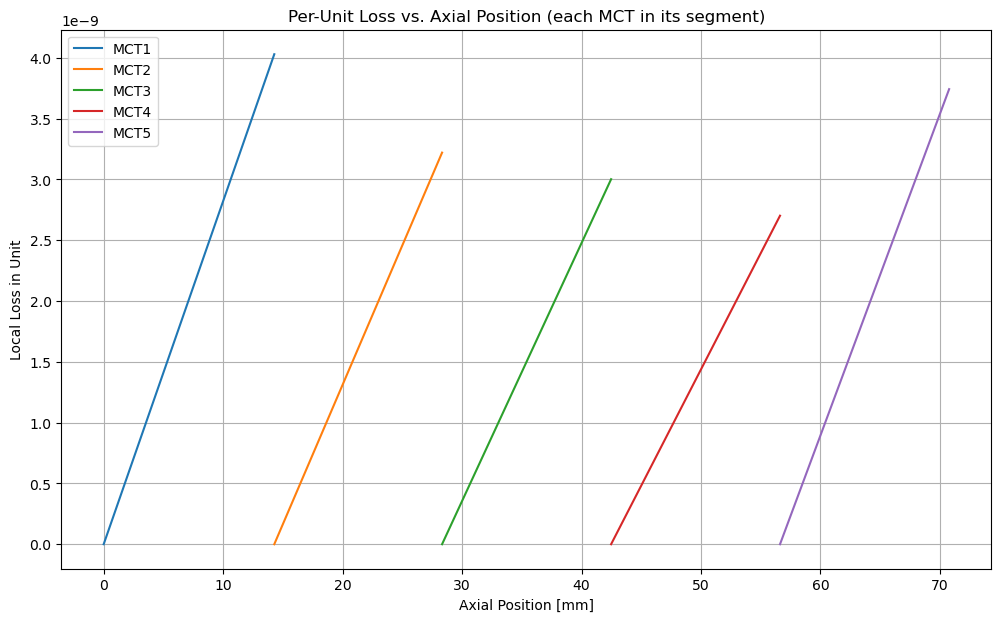

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Given flow rate in m³/s
v1_m3_s = 8.31931129e-5  # m³/s
v1_mm3_min = v1_m3_s * 1e9 * 60  # mm³/min

# Model parameters
models = {
    "MCT1": {"model": "M13", "e12": 6.18786277e-3, "e21": 4.05844408e-3, "e23": 1.19615856e-3},
    "MCT2": {"model": "M02", "e12": 1.14461547e-3},
    "MCT3": {"model": "M02", "e12": 1.05907720e-3},
    "MCT4": {"model": "M02", "e12": 9.53890687e-4},
    "MCT5": {"model": "M02", "e12": 1.31979413e-3},
}

# Compute theta for each model
for name, params in models.items():
    if params["model"] == "M13":
        numerator = params["e12"] * params["e23"]
        denominator = v1_mm3_min * (params["e21"] + params["e23"])
        theta = numerator / denominator
    else:
        theta = params["e12"] / v1_mm3_min
    params["theta"] = theta

# Provided axial positions for UOs
uo_positions_mm = np.array([
    0.0,
    14.28070634,
    28.32597297,
    42.47523083,
    56.61385665,
    70.76956106,
    84.72303724,
    98.946101
])

num_cells_per_uo = 20

# Compute cell boundaries (edges)
cell_edges = []
for i in range(len(uo_positions_mm) - 1):
    start = uo_positions_mm[i]
    end = uo_positions_mm[i + 1]
    edges = np.linspace(start, end, num_cells_per_uo + 1)
    if i == 0:
        cell_edges.extend(edges)
    else:
        cell_edges.extend(edges[1:])  # skip duplicate edge

cell_edges = np.array(cell_edges)

# Compute Loss at each boundary for each model
loss_profiles_edges = {}
for name, params in models.items():
    theta = params["theta"]
    loss = 1 - np.exp(-theta * cell_edges)
    loss_profiles_edges[name] = loss

# Prepare Option 1: Local Loss per Unit, plotted only in its own physical segment

# For each UO, compute its local positions and local Loss
piecewise_loss = []  # list of tuples (x_local, loss_local, model_name)

for i, (name, params) in enumerate(models.items()):
    # Get unit boundaries
    start = uo_positions_mm[i]
    end = uo_positions_mm[i + 1]
    edges = np.linspace(start, end, num_cells_per_uo + 1)

    # Use boundaries: loss per unit is relative to unit start
    dx_local = edges - start  # relative positions within unit
    theta = params["theta"]
    loss_local = 1 - np.exp(-theta * dx_local)

    piecewise_loss.append((edges, loss_local, name))

# Plot piecewise Loss: each segment only in its unit range
plt.figure(figsize=(12, 7))

for x_seg, loss_seg, name in piecewise_loss:
    plt.plot(x_seg, loss_seg, label=name)
    
print(piecewise_loss)

plt.xlabel("Axial Position [mm]")
plt.ylabel("Local Loss in Unit")
plt.title("Per-Unit Loss vs. Axial Position (each MCT in its segment)")
plt.legend()
plt.grid(True)
plt.show()




In [50]:
# Prepare compact summary table: one row per unit
summary_rows = []

for i, (name, params) in enumerate(models.items()):
    start = uo_positions_mm[i]
    end = uo_positions_mm[i + 1]
    L_unit = end - start
    dx_cell = L_unit / num_cells_per_uo
    theta = params["theta"]

    per_cell_loss = 1 - np.exp(-theta * dx_cell)
    total_unit_loss = 1 - (1 - per_cell_loss) ** num_cells_per_uo

    summary_rows.append({
        "Unit": name,
        "Unit_Length_mm": L_unit,
        "Per_Cell_Length_mm": dx_cell,
        "Per_Cell_Loss": per_cell_loss,
        "Total_Unit_Loss": total_unit_loss
    })

# Create DataFrame
summary_df = pd.DataFrame(summary_rows)
summary_df


,Unit,Unit_Length_mm,Per_Cell_Length_mm,Per_Cell_Loss,Total_Unit_Loss
0,MCT1,14.280706,0.714035,2.014979e-10,4.029959e-09
1,MCT2,14.045267,0.702263,1.610353e-10,3.220706e-09
2,MCT3,14.149258,0.707463,1.501042e-10,3.002083e-09
3,MCT4,14.138626,0.706931,1.350944e-10,2.701888e-09
4,MCT5,14.155704,0.707785,1.871411e-10,3.742822e-09


Exchange rates (1/min):
MCT1: e12 = 1.239658e-09, e21 = 8.130569e-10, e23 = 2.396349e-10 1/min
MCT1: Effective exchange rate (theta*v1) = 1.408606e-03 1/min
MCT2: Effective exchange rate (theta*v1) = 1.144615e-03 1/min
MCT3: Effective exchange rate (theta*v1) = 1.059077e-03 1/min
MCT4: Effective exchange rate (theta*v1) = 9.538907e-04 1/min
MCT5: Effective exchange rate (theta*v1) = 1.319794e-03 1/min


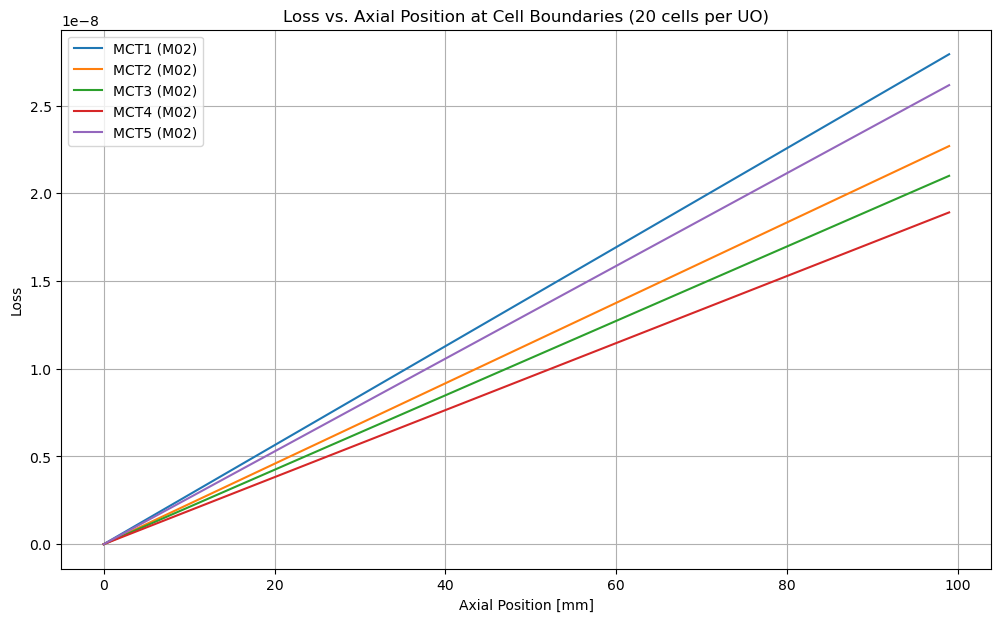

In [52]:
# Given flow rate in m³/s
v1_m3_s = 8.31931129e-5  # m³/s
v1_mm3_min = v1_m3_s * 1e9 * 60  # mm³/min

# Model parameters
models = {
    "MCT1": {"model": "M13", "e12": 6.18786277e-3, "e21": 4.05844408e-3, "e23": 1.19615856e-3},
    "MCT2": {"model": "M02", "e12": 1.14461547e-3},
    "MCT3": {"model": "M02", "e12": 1.05907720e-3},
    "MCT4": {"model": "M02", "e12": 9.53890687e-4},
    "MCT5": {"model": "M02", "e12": 1.31979413e-3},
}

# Compute theta and individual exchange rates for each model
for name, params in models.items():
    if params["model"] == "M13":
        # M13 has 3 rate constants: e12, e21, e23 all in 1/min
        e12_rate = params["e12"] / v1_mm3_min
        e21_rate = params["e21"] / v1_mm3_min
        e23_rate = params["e23"] / v1_mm3_min
        params["e12_rate_per_min"] = e12_rate
        params["e21_rate_per_min"] = e21_rate
        params["e23_rate_per_min"] = e23_rate

        numerator = params["e12"] * params["e23"]
        denominator = v1_mm3_min * (params["e21"] + params["e23"])
        theta = numerator / denominator
    else:
        theta = params["e12"] / v1_mm3_min
    params["theta"] = theta

    # Overall exchange rate in 1/min: theta * v1_mm3_min
    exchange_rate = theta * v1_mm3_min
    params["exchange_rate_per_min"] = exchange_rate

# Print exchange rates per minute
print("Exchange rates (1/min):")
for name, params in models.items():
    if params["model"] == "M13":
        print(f"{name}: e12 = {params['e12_rate_per_min']:.6e}, e21 = {params['e21_rate_per_min']:.6e}, e23 = {params['e23_rate_per_min']:.6e} 1/min")
    print(f"{name}: Effective exchange rate (theta*v1) = {params['exchange_rate_per_min']:.6e} 1/min")

# Plot Loss vs axial position at boundaries
uo_positions_mm = np.array([
    0.0,
    14.28070634,
    28.32597297,
    42.47523083,
    56.61385665,
    70.76956106,
    84.72303724,
    98.946101
])

num_cells_per_uo = 20

cell_edges = []
for i in range(len(uo_positions_mm) - 1):
    start = uo_positions_mm[i]
    end = uo_positions_mm[i + 1]
    edges = np.linspace(start, end, num_cells_per_uo + 1)
    if i == 0:
        cell_edges.extend(edges)
    else:
        cell_edges.extend(edges[1:])

cell_edges = np.array(cell_edges)

loss_profiles_edges = {}
for name, params in models.items():
    theta = params["theta"]
    loss = 1 - np.exp(-theta * cell_edges)
    loss_profiles_edges[name] = loss

plt.figure(figsize=(12, 7))
for name, loss in loss_profiles_edges.items():
    plt.plot(cell_edges, loss, label=f"{name} ({params['model']})")

plt.xlabel("Axial Position [mm]")
plt.ylabel("Loss")
plt.title("Loss vs. Axial Position at Cell Boundaries (20 cells per UO)")
plt.legend()
plt.grid(True)
plt.show()


   Unit   Start_mm     End_mm  Delta_x_mm        Loss_M
0  MCT1   0.000000  14.280706   14.280706  2.417975e-07
1  MCT2  14.280706  28.325973   14.045267  1.932423e-07
2  MCT3  28.325973  42.475231   14.149258  1.801249e-07
3  MCT4  42.475231  56.613857   14.138626  1.621132e-07
4  MCT5  56.613857  70.769561   14.155704  2.245692e-07


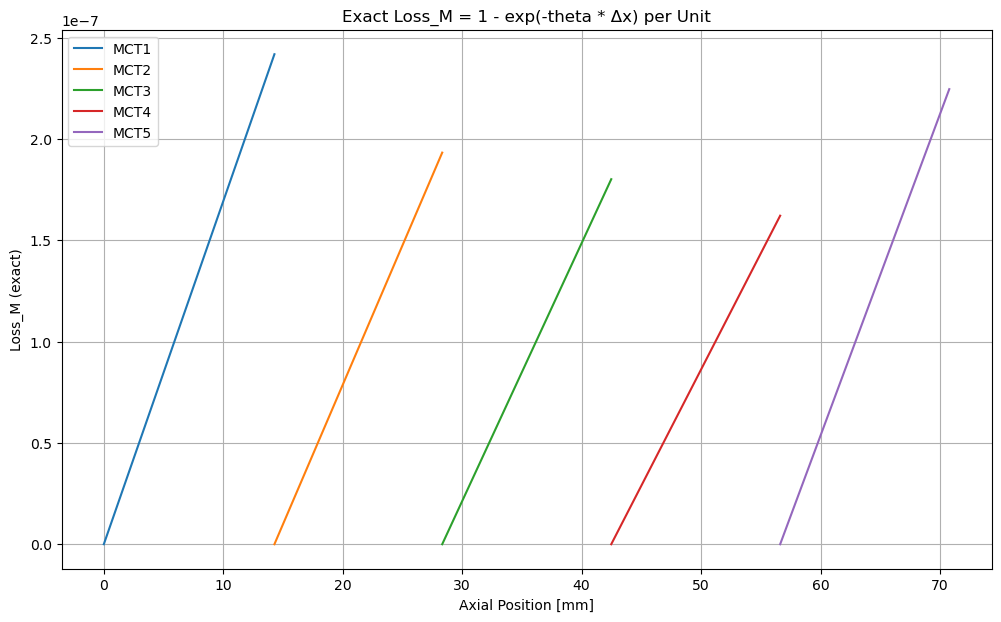

In [57]:
import numpy as np
import pandas as pd

# Given flow rate in m³/s
v1_m3_s = 8.31931129e-5
v1_mm3_s = v1_m3_s * 1e9
v1_mm3_min = v1_mm3_s * 60

# Model parameters
models = {
    "MCT1": {"model": "M13", "e12": 6.18786277e-3 * 60, "e21": 4.05844408e-3 * 60, "e23": 1.19615856e-3 * 60},
    "MCT2": {"model": "M02", "e12": 1.14461547e-3 * 60},
    "MCT3": {"model": "M02", "e12": 1.05907720e-3 * 60},
    "MCT4": {"model": "M02", "e12": 9.53890687e-4 * 60},
    "MCT5": {"model": "M02", "e12": 1.31979413e-3 * 60},
}

# Compute theta
for name, params in models.items():
    if params["model"] == "M13":
        theta = (params["e12"] * params["e23"]) / (v1_mm3_min * (params["e21"] + params["e23"]))
    else:
        theta = params["e12"] / v1_mm3_min
    params["theta"] = theta

uo_positions_mm = np.array([
    0.0, 14.28070634, 28.32597297, 42.47523083,
    56.61385665, 70.76956106, 84.72303724, 98.946101
])

# Compute exact Loss for each Unit over its total Delta x (start to end)
unit_loss_rows = []
for i, (name, params) in enumerate(models.items()):
    start = uo_positions_mm[i]
    end = uo_positions_mm[i + 1]
    delta_x = end - start
    loss_unit = 1 - np.exp(-params["theta"] * delta_x)
    unit_loss_rows.append({
        "Unit": name,
        "Start_mm": start,
        "End_mm": end,
        "Delta_x_mm": delta_x,
        "Loss_M": loss_unit
    })

unit_loss_table = pd.DataFrame(unit_loss_rows)

#import ace_tools as tools; tools.display_dataframe_to_user(name="Exact Unit Loss Table", dataframe=unit_loss_table)

print(unit_loss_table)
# Plot again
plt.figure(figsize=(12, 7))
for x_seg, loss_seg, name in [(r["Axial_Position_mm"].values, r["Loss_M"].values, k) for k, r in loss_table.groupby("Unit")]:
    plt.plot(x_seg, loss_seg, label=name)

plt.xlabel("Axial Position [mm]")
plt.ylabel("Loss_M (exact)")
plt.title("Exact Loss_M = 1 - exp(-theta * Δx) per Unit")
plt.legend()
plt.grid(True)
plt.show()



In [29]:
def plot_pretty(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,60*5)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]
    mct4 = process.flow_sheet.units[5]
    mct5 = process.flow_sheet.units[6]
    


    lenghts = [x / 1000 for x in xi]

    eval_location1 = lenghts[0:1] 
    eval_location2 = list(np.array(lenghts[1:2])-lenghts[1])
    eval_location3 = list(np.array(lenghts[2:3])-lenghts[2])
    eval_location4 = list(np.array(lenghts[3:4])-lenghts[3])
    eval_location5 = list(np.array(lenghts[4:])-lenghts[4])

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 = np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 = np.atleast_2d(np.sum(cb_mct3, axis=2).squeeze()).T

    cb_mct4 = interpolate_cb_from_simulation_results(simulation_results, mct4, time_new, axial_positions_new = eval_location4)
    calc_data_mct4 = np.atleast_2d(np.sum(cb_mct4, axis=2).squeeze()).T
    
    cb_mct5 = interpolate_cb_from_simulation_results(simulation_results, mct5, time_new, axial_positions_new = eval_location5)
    calc_data_mct5 = np.sum(cb_mct5, axis=2).squeeze()


    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3,calc_data_mct4, calc_data_mct5))
    calc_data = calc_data/np.max(calc_data)
    
    #plt.plot(t,calc_data, label="mct1", linewidth=1)
    #plt.gca().set_prop_cycle(None)
    
    plt.style.use('default')
    
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)


    plt.plot(t,calc_data[:,0:1], label="ROI 1", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0], linewidth=1.5)
    plt.plot(t,calc_data[:,1:2], label="ROI 2", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1], linewidth=1.5)
    plt.plot(t,calc_data[:,2:3], label="ROI 3", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2], linewidth=1.5)
    plt.plot(t,calc_data[:,3:4], label="ROI 4", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][3], linewidth=1.5)
    plt.plot(t,calc_data[:,4:5], label="ROI 5", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][4], linewidth=1.5)
    
    plt.plot(t,exp_data[:,0:1],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0], markersize=8)
    plt.plot(t,exp_data[:,1:2],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1], markersize=8)
    plt.plot(t,exp_data[:,2:3],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2], markersize=8)
    plt.plot(t,exp_data[:,3:4],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][3], markersize=8)
    plt.plot(t,exp_data[:,4:5],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][4], markersize=8)

    # Remove duplicate labels
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_handles_labels = dict(zip(labels, handles))  # Remove duplicates
    


    # Add legend with unique labels
    plt.legend(unique_handles_labels.values(), unique_handles_labels.keys(),fontsize=12)
    
    plt.xlabel("Time [min]", fontsize=16)
    plt.ylabel("Activity [a.u.]", fontsize=16)
    plt.savefig("exchange_M02first.pdf", format="pdf")  

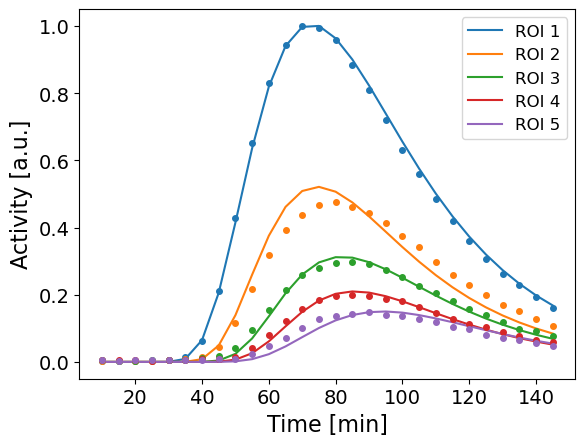

In [30]:
plot_pretty([0.24313021, 0.62711628, 0.69190438, 0.63372977, 0.61087941,
       0.61891478, 0.6166637 , 0.67030876, 0.51596319, 0.09999998,
       0.50361153, 0.55190347, 0.54660793, 0.592952  , 0.71336519,
       0.61428639, 0.88425091])

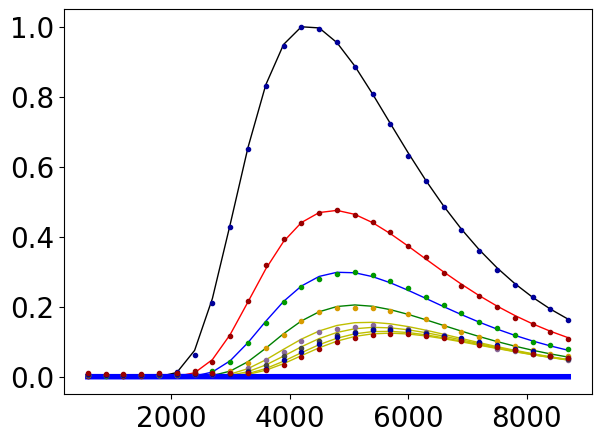

[8.31931129e-05 6.18786277e-03 4.05844408e-03 1.19615856e-03
 1.14461547e-03 1.05907720e-03 9.53890687e-04 1.31979413e-03
 2.54680246e-08 3.16227766e-16 3.56839202e-07 2.11543419e-06
 1.08250263e-06 4.74840383e-01 7.11469234e-07 1.75464386e-01
 1.75497788e+00] [-3.53155634e-03 -3.47484672e-03 -4.27753948e-03 -4.26588133e-03
 -5.03233264e-03 -5.47022845e-03 -6.64686559e-03 -1.09399127e-02
 -3.82784655e-03 -3.83700643e-03 -3.34198423e-03 -4.27034648e-03
 -4.01809875e-03 -5.04792008e-03 -5.76933936e-03 -8.16750974e-03
 -3.52971138e-03 -3.36319174e-03 -3.88538426e-03 -4.29891417e-03
 -4.35149585e-03 -4.41312913e-03 -6.33552564e-03 -7.73311638e-03
 -3.90664636e-03 -3.40101253e-03 -4.39359877e-03 -4.00689013e-03
 -4.35966051e-03 -5.38489805e-03 -5.88995037e-03 -8.93933644e-03
 -4.41929082e-03 -5.77026627e-03 -5.18289276e-03 -4.63751906e-03
 -4.39123084e-03 -5.07374789e-03 -7.96865413e-03 -1.05116543e-02
 -1.62812120e-03 -8.28861418e-03 -7.03311685e-03 -5.50956956e-03
 -5.73608643e-03 -5.8237

In [27]:
x_best_fit = [0.38522691, 0.68945403, 0.67324479, 0.6262959 , 0.62460321,
       0.62161835, 0.61759845, 0.63007586, 0.64661502, 0.1       ,
       0.44405907, 0.54067494, 0.50430362, 0.42116897, 0.67941026,
       0.57056685, 0.87104099]


def compute_jacobian(f, x, eps=None):
    """Computes numerical Jacobian using central difference with adaptive epsilon."""
    x = np.asarray(x)
    n_params = len(x)
    f_x = np.asarray(f(x)).ravel()
    n_outputs = len(f_x)
    J = np.zeros((n_outputs, n_params))

    if eps is None:
        eps = np.sqrt(np.finfo(float).eps) * np.maximum(1.0, np.abs(x))

    for i in range(n_params):
        x_step = np.zeros_like(x)
        x_step[i] = eps[i]

        f_plus = np.asarray(f(x + x_step)).ravel()
        f_minus = np.asarray(f(x - x_step)).ravel()

        J[:, i] = (f_plus - f_minus) / (2 * eps[i])

    return J



# Compute the Jacobian
J = compute_jacobian(mct_obj_res, x_best_fit)

# Step 3: Compute the covariance matrix
JTJ_inv = np.linalg.pinv(J.T @ J)
sigma_squared = np.var(mct_obj_res(x_best_fit))  # Estimate variance of residuals
C = JTJ_inv * sigma_squared  # Covariance matrix

# Step 4: Compute parameter uncertainties
param_uncertainties = np.sqrt(np.abs(np.diag(C)))  # Extract uncertainties
rel_param_uncertanties = param_uncertainties / np.abs(x_best_fit)

# Print results
for i, uncertainty in enumerate(rel_param_uncertanties):
    print(f"Parameter {i}: ±{uncertainty*100}%")

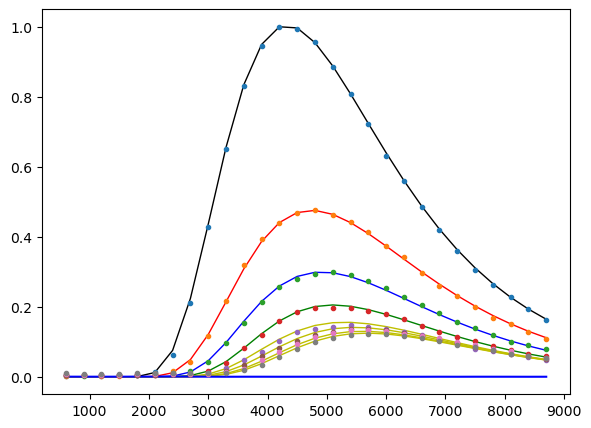

In [61]:
result = mct_full_result([0.38522691, 0.68945403, 0.67324479, 0.6262959 , 0.62460321,
       0.62161835, 0.61759845, 0.63007586, 0.64661502, 0.1       ,
       0.44405907, 0.54067494, 0.50430362, 0.42116897, 0.67941026,
       0.57056685, 0.87104099])

In [64]:
import numpy as np
from scipy.stats import linregress
from scipy.interpolate import interp1d


# === Compute 50% cumulative integral time for each pulse ===
median_times = []

for i in range(result.shape[1]):
    signal = result[:, i]
    # Trapezoidal cumulative integral
    cumulative = np.cumsum((signal[:-1] + signal[1:]) / 2 * np.diff(t))
    cumulative = np.insert(cumulative, 0, 0)  # same length
    total = cumulative[-1]
    target = 0.5 * total

    # Interpolate: cumulative -> time
    f_interp = interp1d(cumulative, t, bounds_error=False, fill_value="extrapolate")
    t50 = f_interp(target)
    median_times.append(t50)

median_times = np.array(median_times)

# === Global linear fit ===
slope, intercept, r_value, p_value, std_err = linregress(median_times, xi)

# Compute relative uncertainty
relative_uncertainty = std_err / abs(slope)

print(f"Global velocity: {slope:.3f} mm/min")
print(f"Global relative uncertainty: {relative_uncertainty:.3%}")

# === Pairwise velocities (no uncertainty) ===
pairwise_velocities = []

for i in range(len(xi) - 1):
    x_pair = xi[i:i+2]
    t_pair = median_times[i:i+2]
    slope_pair, _, _, _, _ = linregress(t_pair, x_pair)
    pairwise_velocities.append(slope_pair)

pairwise_velocities = np.array(pairwise_velocities)

print(f"Pairwise velocities (mm/min): {pairwise_velocities}")



Global velocity: 5.300 mm/min
Global relative uncertainty: 9.321%
Pairwise velocities (mm/min): [ 2.32898364  5.707988    5.42529546  5.29479624  6.99393377  7.91617225
 14.4980823 ]


In [66]:
xi

[0.0,
 14.28070634,
 28.32597297,
 42.47523083,
 56.61385665,
 70.76956106,
 84.72303724,
 98.946101]

In [65]:
import numpy as np
from scipy.interpolate import UnivariateSpline
from scipy.stats import linregress


# === 1. Find half-max crossing using spline ===
t_half = []

for i in range(result.shape[1]):
    y = result[:, i]
    y_max = np.max(y)
    half_max = y_max / 2

    # Fit a smoothing spline: s=0 means interpolation, s>0 means smoothing
    spline = UnivariateSpline(t, y - half_max, s=0)

    # Find all roots: possible multiple crossings → take first on rising edge
    roots = spline.roots()
    if len(roots) == 0:
        raise ValueError(f"No half-max crossing found for pulse {i}")

    # Take the smallest root (earliest crossing)
    t_cross = np.min(roots)
    t_half.append(t_cross)

t_half = np.array(t_half)

# === 2. Fit each consecutive pair: position vs. half-max time ===
velocities = []
velocity_errors = []

for i in range(len(xi) - 1):
    pos_pair = xi[i:i+2]
    time_pair = t_half[i:i+2]

    slope, intercept, r_value, p_value, std_err = linregress(time_pair, pos_pair)

    velocities.append(slope)
    velocity_errors.append(std_err)

velocities = np.array(velocities)
velocity_errors = np.array(velocity_errors)

print("Spline-based half-max times (min):", t_half)
print("Velocities (mm/min):", velocities)
print("Uncertainties (mm/min):", velocity_errors)

# === Optional: global mean velocity ===
slope, intercept, r_value, p_value, std_err = linregress(t_half, xi)
print("Global mean velocity (mm/min):", slope)
print("Global uncertainty (mm/min):", std_err)


Spline-based half-max times (min): [51.42923695 56.2231146  59.24014962 62.51378606 64.87957372 67.14745625
 69.22826501 70.44348038]
Velocities (mm/min): [ 2.97894677  4.65532104  4.32218364  5.9762869   6.24181555  6.7057946
 11.70415066]
Uncertainties (mm/min): [0. 0. 0. 0. 0. 0. 0.]
Global mean velocity (mm/min): 5.140216619227981
Global uncertainty (mm/min): 0.3582862922758391
